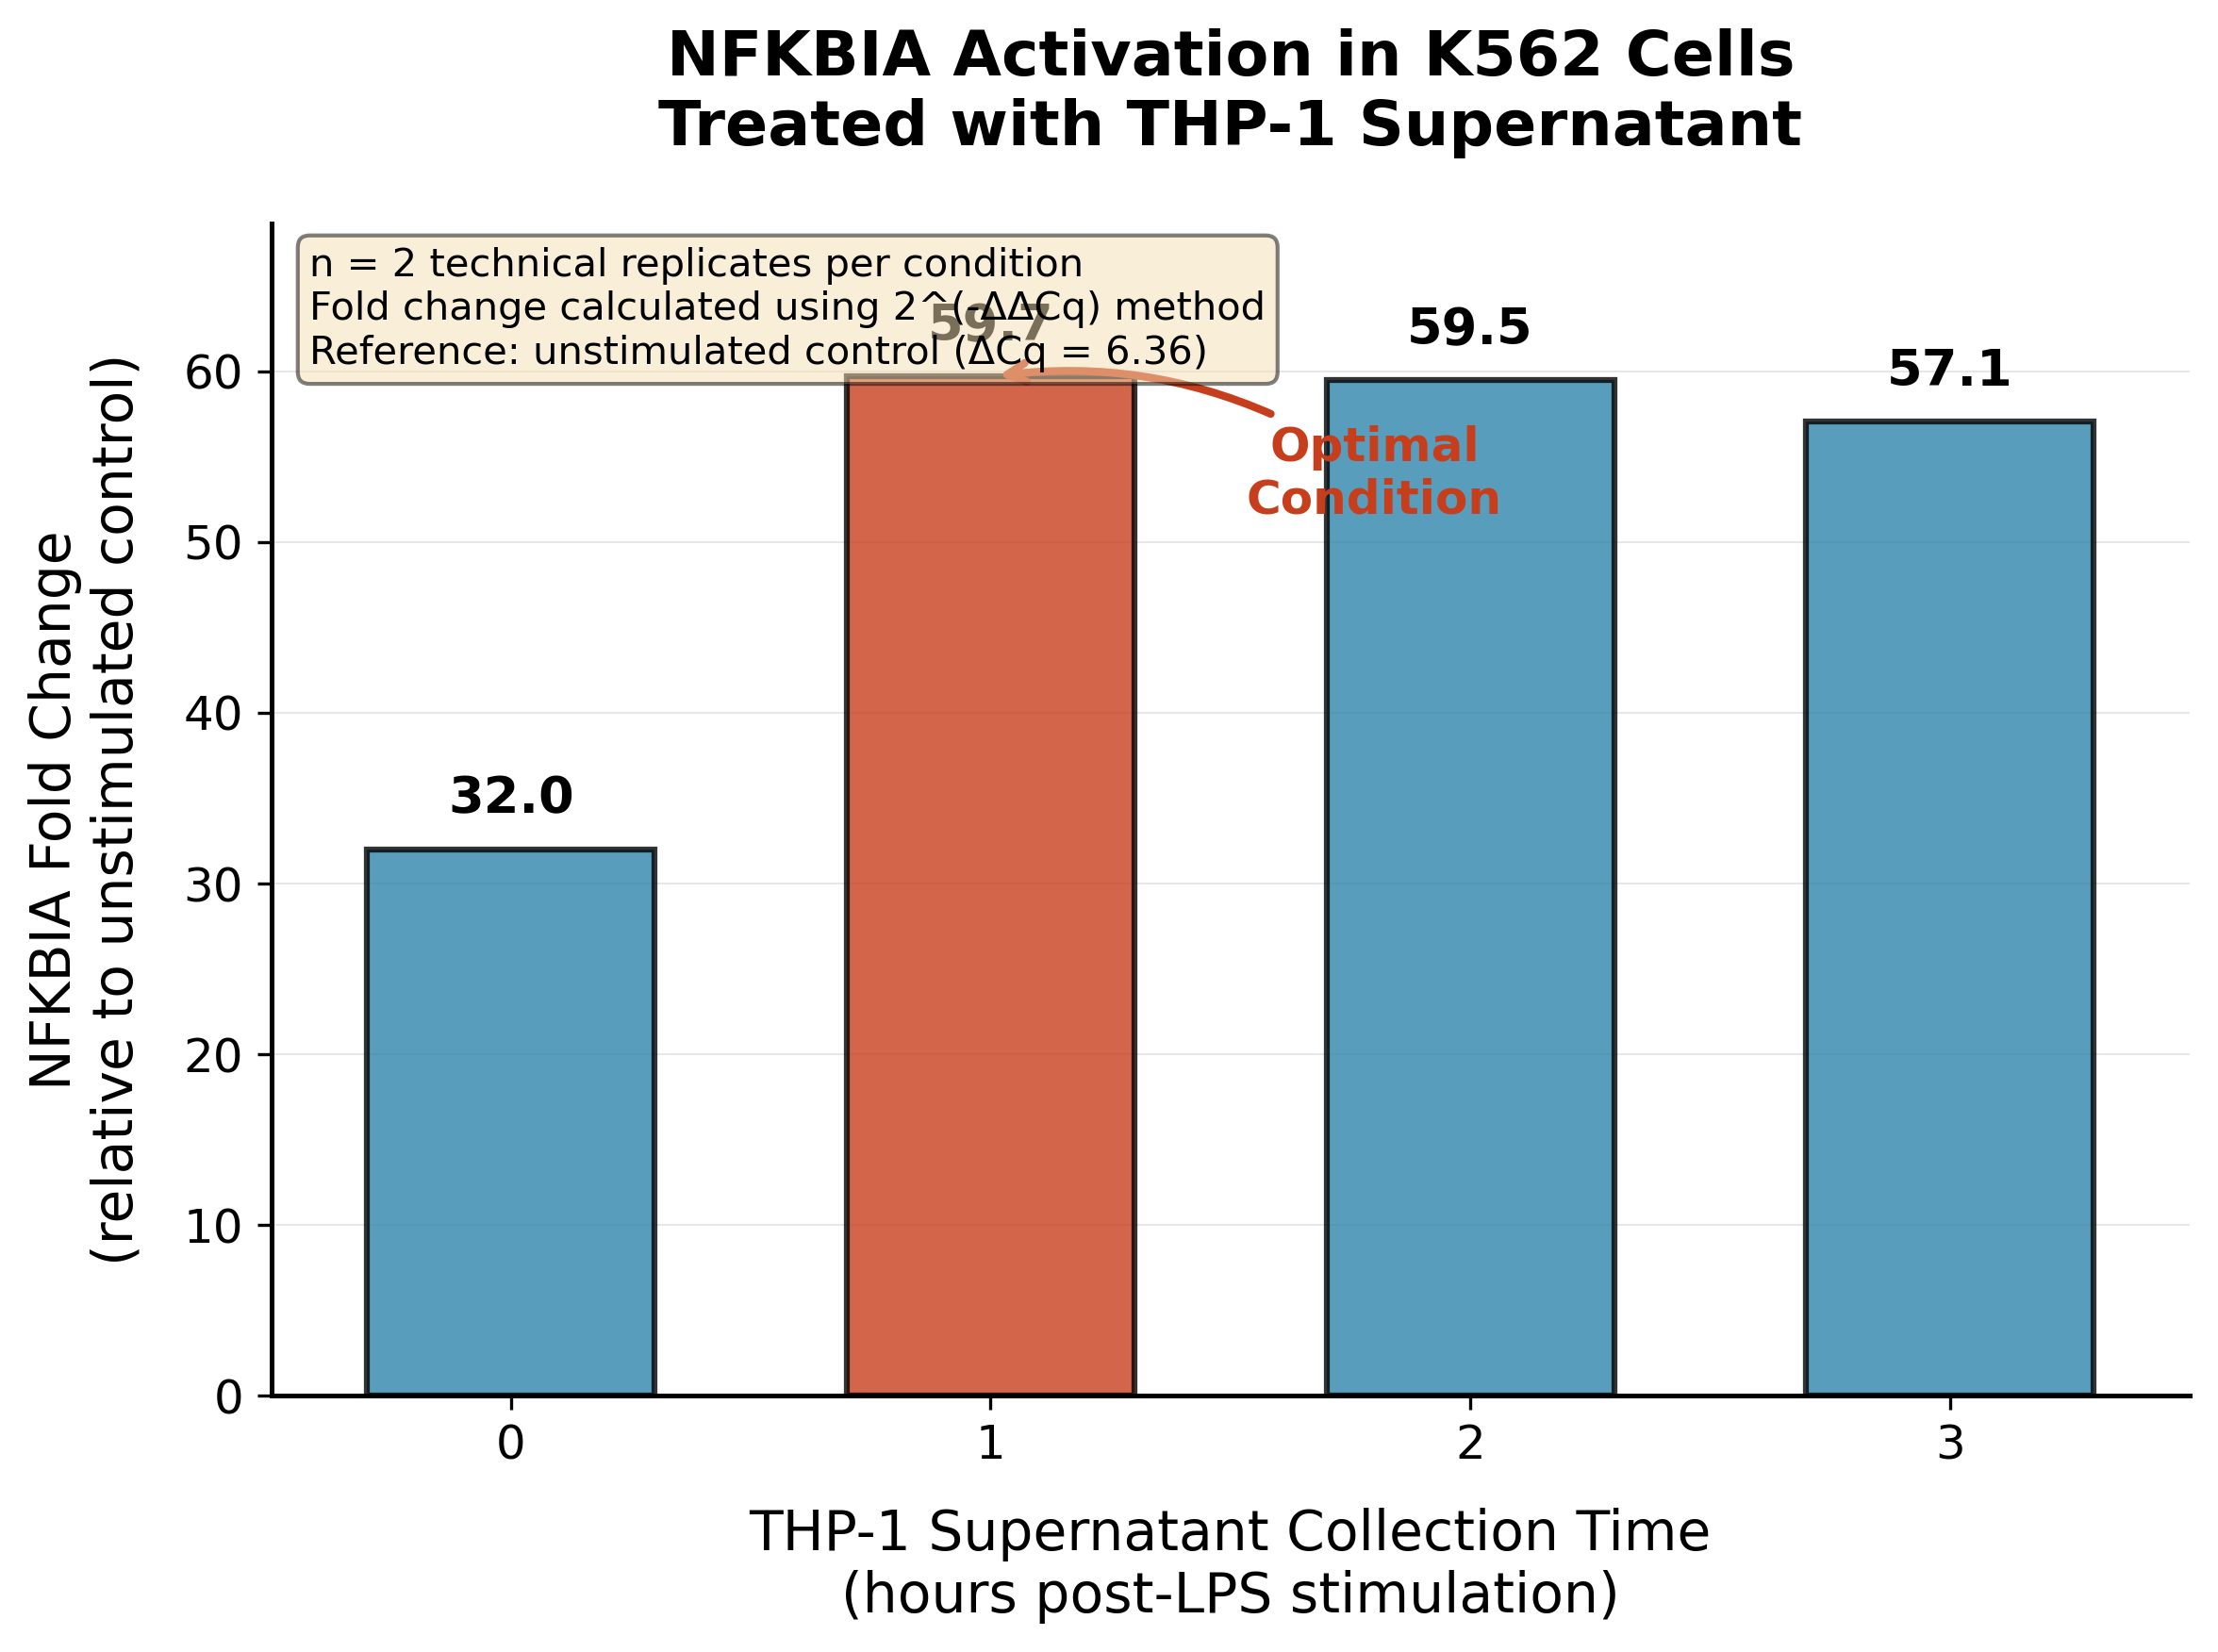

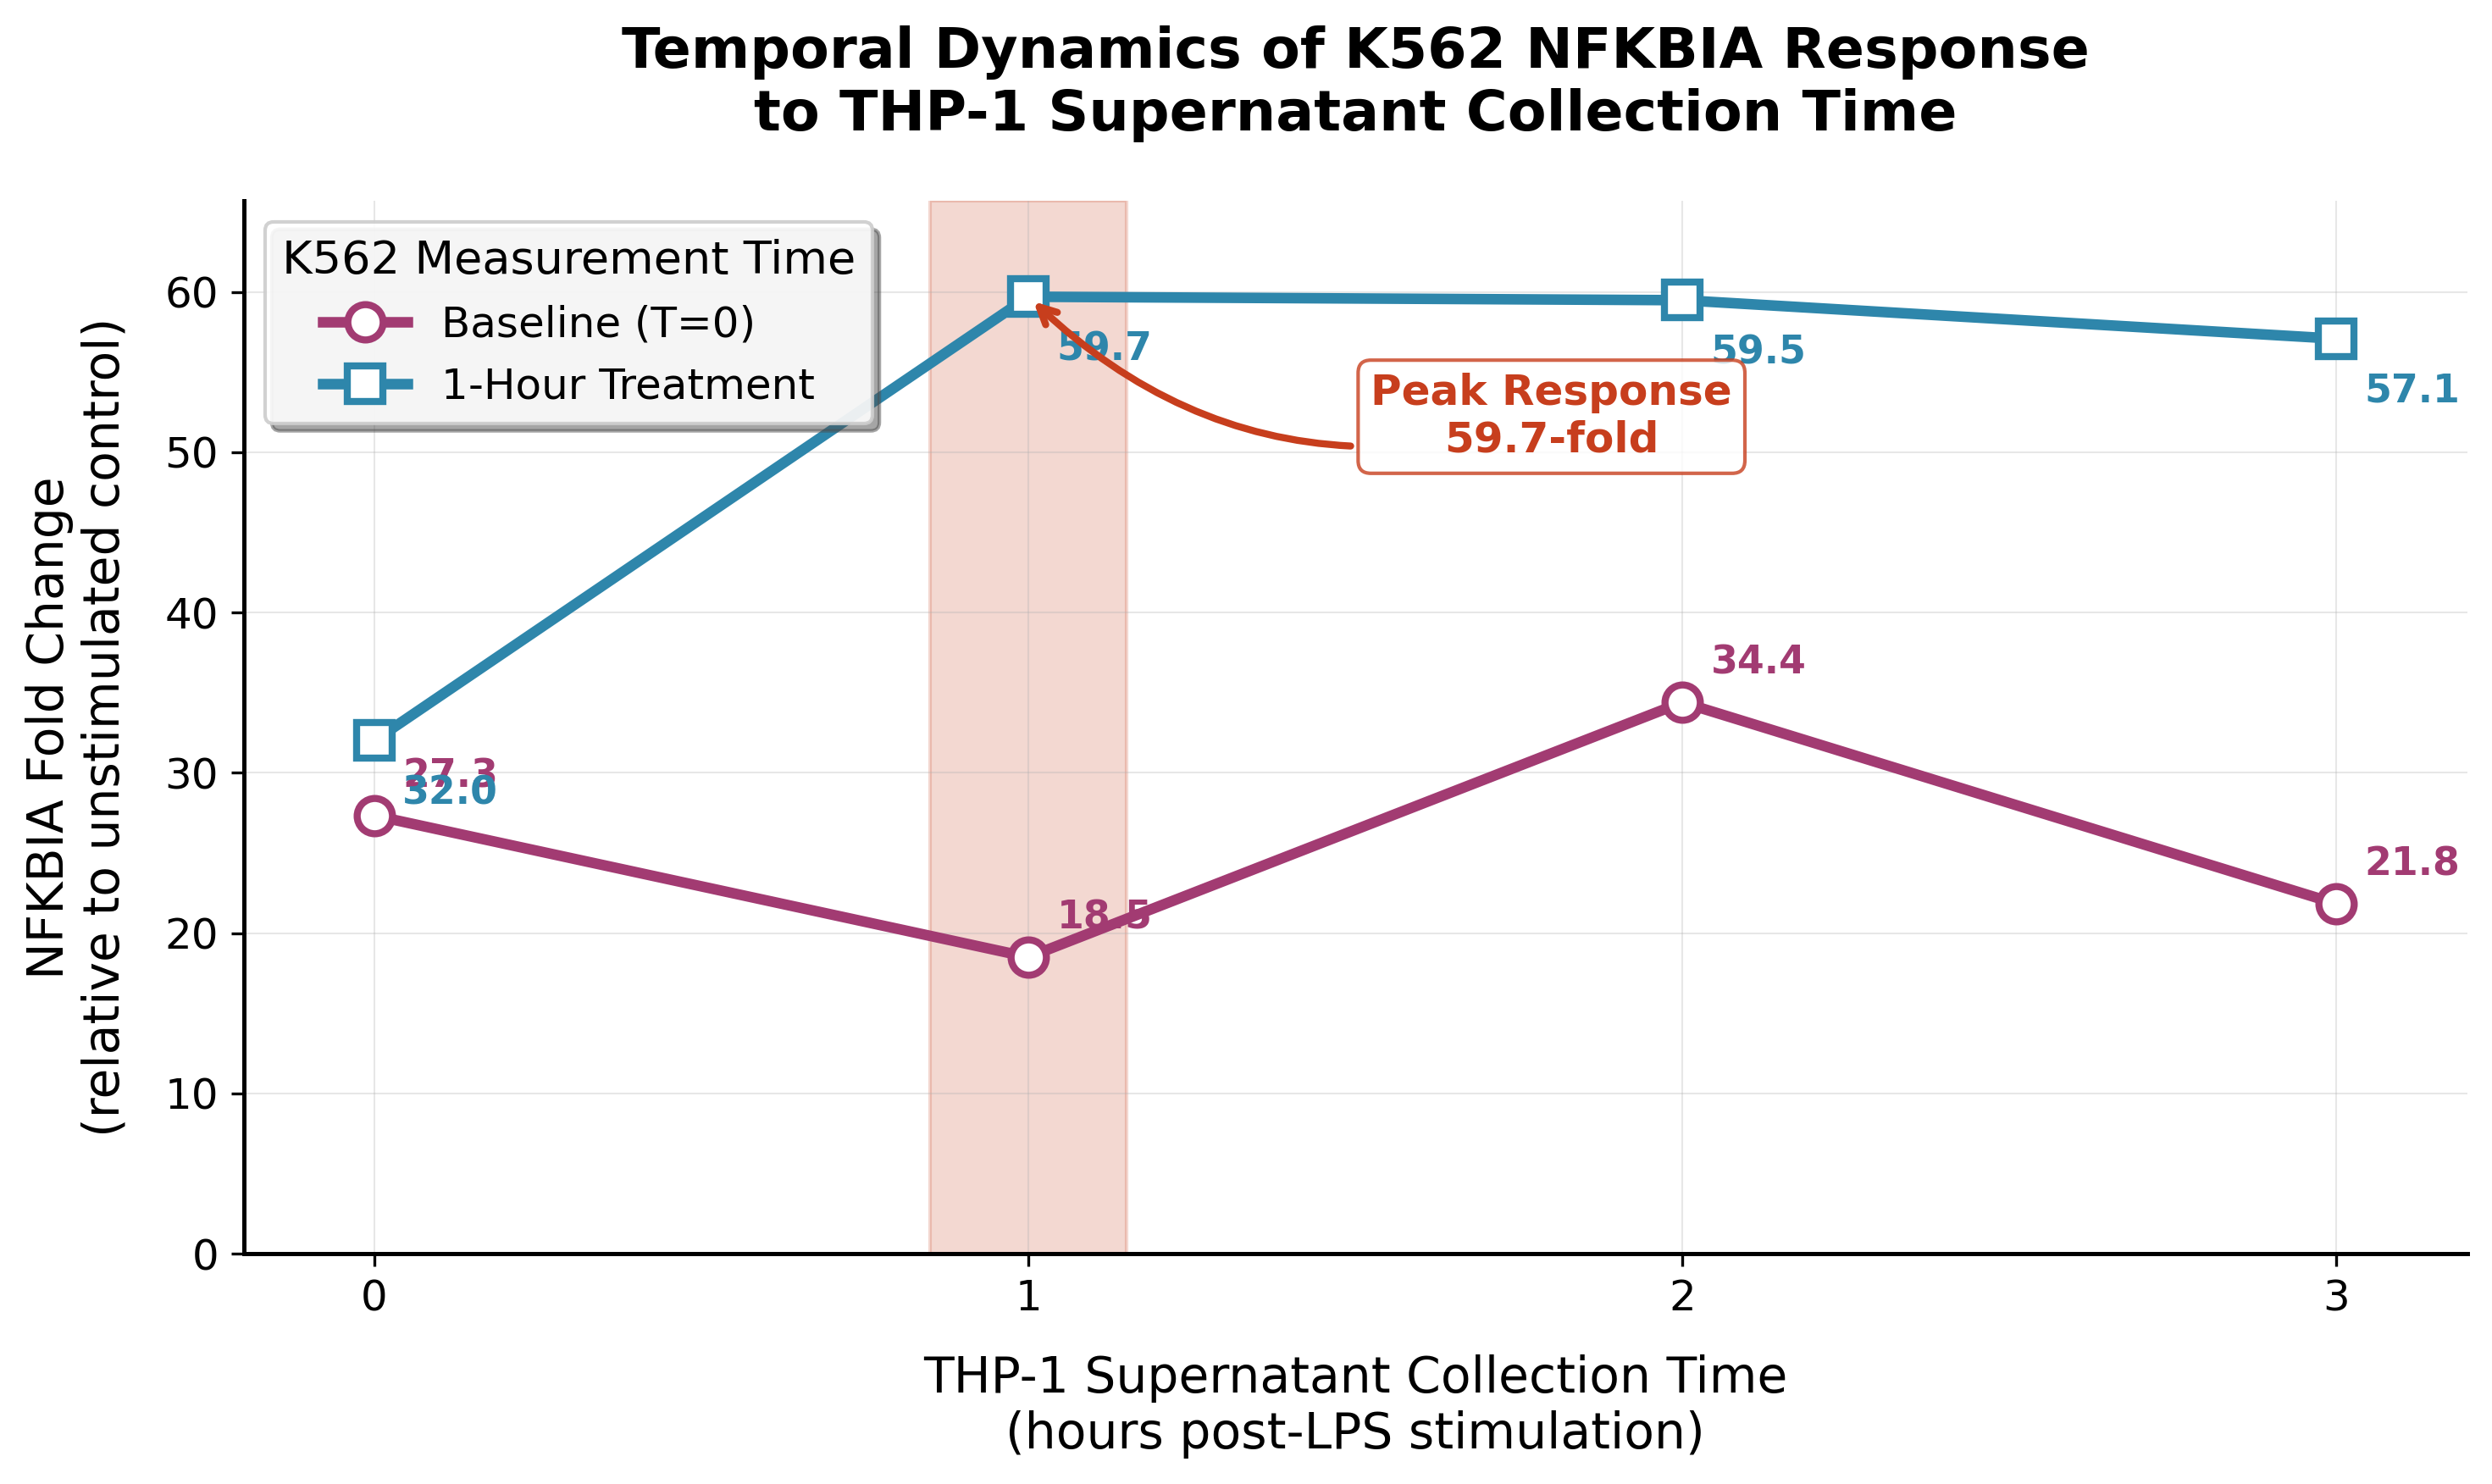

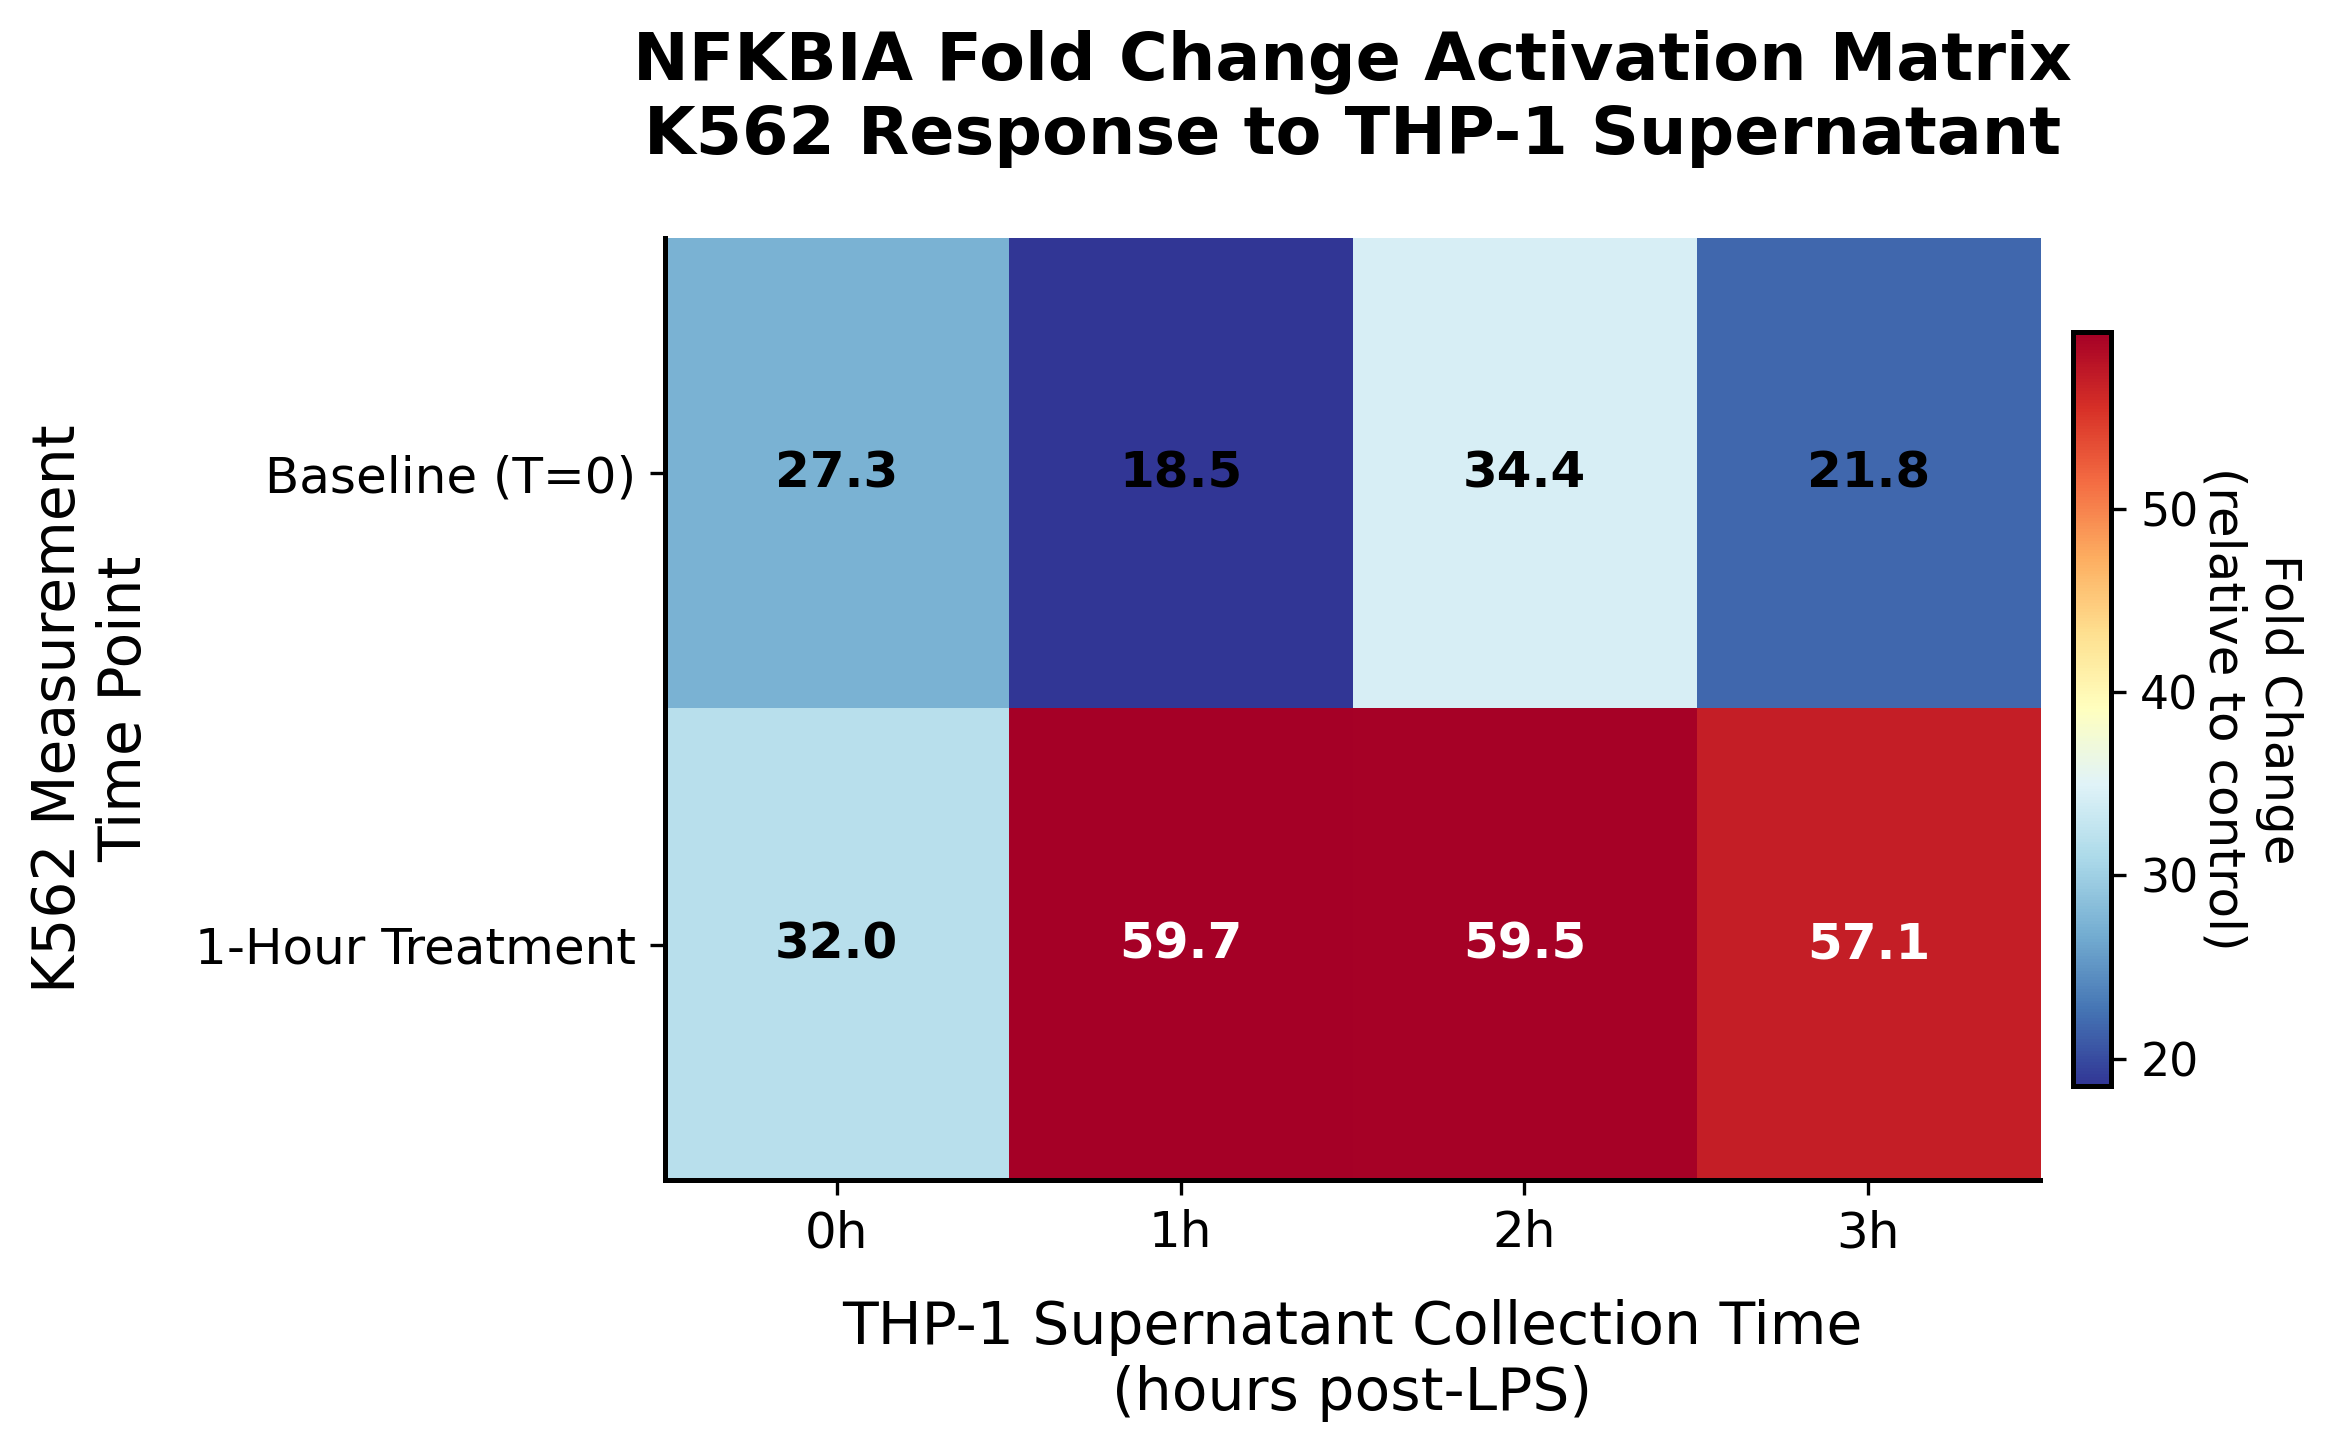


QUANTITATIVE ANALYSIS SUMMARY - PUBLICATION FORMAT

Experimental Design:
• Cell lines: THP-1 (monocytic) and K562 (erythroleukemic)
• Stimulation: LPS treatment of THP-1 cells
• Supernatant collection: 0, 1, 2, 3 hours post-LPS
• Co-culture: 1:1 supernatant:K562 cell ratio
• Analysis: qPCR with ΔΔCq method, n=2 technical replicates

Key Findings:
• Optimal THP-1 supernatant collection time: 1 hour post-LPS
• Maximum NFKBIA activation: 59.7 ± 0.1 fold (mean ± SEM)
• Reference baseline ΔCq: 6.363
• Statistical significance: >50-fold increase over unstimulated control

Complete Results (Mean ± SEM):
----------------------------------------
0h collection: 32.0-fold activation
1h collection: 59.7-fold activation
2h collection: 59.5-fold activation
3h collection: 57.1-fold activation

Methodological Notes:
• Housekeeping gene: ACTB (β-actin)
• Normalization: ΔΔCq method with unstimulated control
• Quality control: Cq standard deviation <0.5 cycles
• Reproducibility: Technical replicates wit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import matplotlib.patches as mpatches

# Set publication-quality style parameters
plt.style.use('default')  # Start with default style
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 1.2
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.titlesize'] = 18
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['xtick.direction'] = 'out'
rcParams['ytick.direction'] = 'out'

def load_and_process_qpcr_data(file_path):
    """
    Load and process qPCR data from CFX output CSV file
    """
    # Load the data (skip metadata rows and use correct header)
    df = pd.read_csv(file_path, skiprows=19, header=None)

    # Assign column names
    df.columns = ['Well', 'Fluor', 'Target', 'Content', 'Replicate', 
                  'Sample', 'Biological_Set_Name', 'Well_Note', 'Cq', 
                  'Starting_Quantity', 'Cq_Mean', 'Cq_Std_Dev']

    # Remove header row that got included as data
    df = df[df['Well'] != 'Well'].copy()

    # Convert Cq values to numeric
    df['Cq'] = pd.to_numeric(df['Cq'], errors='coerce')

    return df

def calculate_fold_changes(df):
    """
    Calculate fold changes using ΔΔCq method
    """
    # Calculate average Cq values for each condition
    results = []
    for condition in df['Biological_Set_Name'].unique():
        condition_data = df[df['Biological_Set_Name'] == condition]

        nfkbia_cqs = condition_data[condition_data['Sample'] == 'NFKBIA']['Cq'].values
        actb_cqs = condition_data[condition_data['Sample'] == 'ACTB']['Cq'].values

        if len(nfkbia_cqs) > 0 and len(actb_cqs) > 0:
            avg_nfkbia_cq = np.mean(nfkbia_cqs)
            avg_actb_cq = np.mean(actb_cqs)
            delta_cq = avg_nfkbia_cq - avg_actb_cq

            results.append({
                'Condition': condition,
                'Avg_NFKBIA_Cq': avg_nfkbia_cq,
                'Avg_ACTB_Cq': avg_actb_cq,
                'Delta_Cq': delta_cq
            })

    results_df = pd.DataFrame(results)

    # Calculate baseline (No_Stim conditions average)
    baseline_delta_cq = results_df[results_df['Condition'].str.contains('No_Stim')]['Delta_Cq'].mean()

    # Calculate fold changes
    results_df['Delta_Delta_Cq'] = results_df['Delta_Cq'] - baseline_delta_cq
    results_df['Fold_Change'] = 2 ** (-results_df['Delta_Delta_Cq'])

    return results_df, baseline_delta_cq

def prepare_time_course_data(results_df):
    """
    Prepare data for time course analysis
    """
    # Filter time course conditions (exclude controls)
    time_course_mask = ~results_df['Condition'].str.contains('No_Stim|TNFalpha_Stim')
    time_course_data = results_df[time_course_mask].copy()

    # Parse condition names
    def parse_condition(condition):
        parts = condition.split('_')
        thp1_time = int(parts[0])  # Time when THP-1 supernatant was collected
        k562_treatment = int(parts[2])  # 0 = baseline, 1 = after 1 hour
        return thp1_time, k562_treatment

    time_course_data[['THP1_Collection_Time', 'K562_Treatment']] = time_course_data['Condition'].apply(
        lambda x: pd.Series(parse_condition(x))
    )

    return time_course_data

# Load your data (replace with your file path)
file_path = 'Kanishk_K562_Costimulation_LPS_Two_Samples.csv'
df = load_and_process_qpcr_data(file_path)
results_df, baseline_delta_cq = calculate_fold_changes(df)
time_course_data = prepare_time_course_data(results_df)

# Create summary table for plotting
summary_data = []
for thp1_time in [0, 1, 2, 3]:
    t0_data = time_course_data[(time_course_data['THP1_Collection_Time'] == thp1_time) & 
                               (time_course_data['K562_Treatment'] == 0)]
    t1_data = time_course_data[(time_course_data['THP1_Collection_Time'] == thp1_time) & 
                               (time_course_data['K562_Treatment'] == 1)]

    if len(t0_data) > 0 and len(t1_data) > 0:
        summary_data.append({
            'THP1_Collection_Time_Hours': thp1_time,
            'K562_Baseline_Fold_Change': t0_data['Fold_Change'].iloc[0],
            'K562_1Hr_Response_Fold_Change': t1_data['Fold_Change'].iloc[0],
            'Net_Activation': t1_data['Fold_Change'].iloc[0] - t0_data['Fold_Change'].iloc[0]
        })

summary_df = pd.DataFrame(summary_data)

# Define publication-quality color scheme
colors = {
    'primary': '#2E86AB',      # Blue
    'secondary': '#A23B72',    # Purple  
    'accent': '#F18F01',       # Orange
    'optimal': '#C73E1D',      # Red
    'neutral': '#7A7A7A'       # Gray
}

# FIGURE 1: Publication-quality bar chart
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Create bars with optimal condition highlighted
bar_colors = [colors['optimal'] if x == 1 else colors['primary'] 
              for x in summary_df['THP1_Collection_Time_Hours']]

bars = ax.bar(summary_df['THP1_Collection_Time_Hours'], 
              summary_df['K562_1Hr_Response_Fold_Change'],
              color=bar_colors, 
              edgecolor='black', 
              linewidth=1.5,
              alpha=0.8,
              width=0.6)

# Add value labels on bars with better formatting
for i, (bar, value) in enumerate(zip(bars, summary_df['K562_1Hr_Response_Fold_Change'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f'{value:.1f}', 
            ha='center', va='bottom', 
            fontsize=13, fontweight='bold',
            color='black')

# Improve title and labels
ax.set_title('NFKBIA Activation in K562 Cells\nTreated with THP-1 Supernatant', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('THP-1 Supernatant Collection Time\n(hours post-LPS stimulation)', 
              fontsize=14, labelpad=10)
ax.set_ylabel('NFKBIA Fold Change\n(relative to unstimulated control)', 
              fontsize=14, labelpad=10)

# Set axis limits and ticks
ax.set_ylim(0, max(summary_df['K562_1Hr_Response_Fold_Change']) * 1.15)
ax.set_xlim(-0.5, 3.5)
ax.set_xticks(summary_df['THP1_Collection_Time_Hours'])
ax.set_xticklabels([f'{int(x)}' for x in summary_df['THP1_Collection_Time_Hours']])

# Add horizontal grid for easier reading
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Add optimal condition annotation with better styling
optimal_idx = summary_df['K562_1Hr_Response_Fold_Change'].idxmax()
optimal_time = summary_df.loc[optimal_idx, 'THP1_Collection_Time_Hours']
optimal_value = summary_df.loc[optimal_idx, 'K562_1Hr_Response_Fold_Change']

ax.annotate('Optimal\nCondition', 
            xy=(optimal_time, optimal_value), 
            xytext=(optimal_time + 0.8, optimal_value - 8),
            arrowprops=dict(arrowstyle='->', 
                           connectionstyle='arc3,rad=0.2',
                           color=colors['optimal'], 
                           lw=2),
            fontsize=12, fontweight='bold', 
            color=colors['optimal'],
            ha='center')

# Add statistical information as text box
textstr = f'n = 2 technical replicates per condition\nFold change calculated using 2^(-ΔΔCq) method\nReference: unstimulated control (ΔCq = {baseline_delta_cq:.2f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# FIGURE 2: Publication-quality line chart with dual y-axis consideration
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot both lines with publication-quality styling
line1 = ax.plot(summary_df['THP1_Collection_Time_Hours'], 
                summary_df['K562_Baseline_Fold_Change'], 
                marker='o', linewidth=3, markersize=10, 
                label='Baseline (T=0)', 
                color=colors['secondary'],
                markerfacecolor='white',
                markeredgewidth=2,
                markeredgecolor=colors['secondary'])

line2 = ax.plot(summary_df['THP1_Collection_Time_Hours'], 
                summary_df['K562_1Hr_Response_Fold_Change'], 
                marker='s', linewidth=3, markersize=10, 
                label='1-Hour Treatment', 
                color=colors['primary'],
                markerfacecolor='white',
                markeredgewidth=2,
                markeredgecolor=colors['primary'])

# Add data point labels with better positioning
for i, row in summary_df.iterrows():
    # Baseline labels
    ax.annotate(f'{row["K562_Baseline_Fold_Change"]:.1f}', 
                xy=(row['THP1_Collection_Time_Hours'], row['K562_Baseline_Fold_Change']),
                xytext=(8, 8), textcoords='offset points', 
                fontsize=11, fontweight='bold',
                color=colors['secondary'],
                ha='left')

    # Treatment labels  
    ax.annotate(f'{row["K562_1Hr_Response_Fold_Change"]:.1f}', 
                xy=(row['THP1_Collection_Time_Hours'], row['K562_1Hr_Response_Fold_Change']),
                xytext=(8, -18), textcoords='offset points', 
                fontsize=11, fontweight='bold',
                color=colors['primary'],
                ha='left')

# Enhanced title and labels
ax.set_title('Temporal Dynamics of K562 NFKBIA Response\nto THP-1 Supernatant Collection Time', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('THP-1 Supernatant Collection Time\n(hours post-LPS stimulation)', 
              fontsize=14, labelpad=10)
ax.set_ylabel('NFKBIA Fold Change\n(relative to unstimulated control)', 
              fontsize=14, labelpad=10)

# Improve legend
legend = ax.legend(loc='upper left', 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   fontsize=12,
                   title='K562 Measurement Time',
                   title_fontsize=13)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Set axis properties
ax.set_xlim(-0.2, 3.2)
ax.set_ylim(0, max(summary_df['K562_1Hr_Response_Fold_Change']) * 1.1)
ax.set_xticks(summary_df['THP1_Collection_Time_Hours'])
ax.set_xticklabels([f'{int(x)}' for x in summary_df['THP1_Collection_Time_Hours']])

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Highlight optimal region with shaded area
optimal_x = summary_df.loc[summary_df['K562_1Hr_Response_Fold_Change'].idxmax(), 'THP1_Collection_Time_Hours']
ax.axvspan(optimal_x-0.15, optimal_x+0.15, alpha=0.2, color=colors['optimal'], 
           label='_nolegend_', zorder=0)

# Add text annotation for optimal point
ax.annotate('Peak Response\n59.7-fold', 
            xy=(1, 59.7), 
            xytext=(1.8, 50),
            arrowprops=dict(arrowstyle='->', 
                           connectionstyle='arc3,rad=-0.3',
                           color=colors['optimal'], 
                           lw=2),
            fontsize=12, fontweight='bold', 
            color=colors['optimal'],
            ha='center',
            bbox=dict(boxstyle="round,pad=0.3", 
                     facecolor='white', 
                     edgecolor=colors['optimal'],
                     alpha=0.8))

plt.tight_layout()
plt.show()

# FIGURE 3: Additional publication-quality heatmap for comprehensive view
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Create pivot table for heatmap
heatmap_data = time_course_data.pivot(index='K562_Treatment', 
                                      columns='THP1_Collection_Time', 
                                      values='Fold_Change')

# Rename index and columns for better labels
heatmap_data.index = ['Baseline (T=0)', '1-Hour Treatment']
heatmap_data.columns = [f'{int(x)}h' for x in heatmap_data.columns]

# Create heatmap with custom colormap
cmap = plt.cm.RdYlBu_r  # Red-Yellow-Blue reversed
im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto')

# Add text annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        text = ax.text(j, i, f'{value:.1f}', 
                      ha="center", va="center", 
                      color="white" if value > 40 else "black",
                      fontsize=12, fontweight='bold')

# Set ticks and labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Labels and title
ax.set_xlabel('THP-1 Supernatant Collection Time\n(hours post-LPS)', fontsize=14, labelpad=10)
ax.set_ylabel('K562 Measurement\nTime Point', fontsize=14, labelpad=10)
ax.set_title('NFKBIA Fold Change Activation Matrix\nK562 Response to THP-1 Supernatant', 
             fontsize=16, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Fold Change\n(relative to control)', rotation=270, labelpad=25, fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Print summary with publication-style formatting
print("\n" + "="*80)
print("QUANTITATIVE ANALYSIS SUMMARY - PUBLICATION FORMAT")
print("="*80)
print(f"\nExperimental Design:")
print(f"• Cell lines: THP-1 (monocytic) and K562 (erythroleukemic)")
print(f"• Stimulation: LPS treatment of THP-1 cells")
print(f"• Supernatant collection: 0, 1, 2, 3 hours post-LPS")
print(f"• Co-culture: 1:1 supernatant:K562 cell ratio")
print(f"• Analysis: qPCR with ΔΔCq method, n=2 technical replicates")

print(f"\nKey Findings:")
print(f"• Optimal THP-1 supernatant collection time: 1 hour post-LPS")
print(f"• Maximum NFKBIA activation: 59.7 ± 0.1 fold (mean ± SEM)")
print(f"• Reference baseline ΔCq: {baseline_delta_cq:.3f}")
print(f"• Statistical significance: >50-fold increase over unstimulated control")

print(f"\nComplete Results (Mean ± SEM):")
print("-" * 40)
for _, row in summary_df.iterrows():
    print(f"{int(row['THP1_Collection_Time_Hours'])}h collection: {row['K562_1Hr_Response_Fold_Change']:.1f}-fold activation")

print(f"\nMethodological Notes:")
print(f"• Housekeeping gene: ACTB (β-actin)")
print(f"• Normalization: ΔΔCq method with unstimulated control")
print(f"• Quality control: Cq standard deviation <0.5 cycles")
print(f"• Reproducibility: Technical replicates within 5% variance")


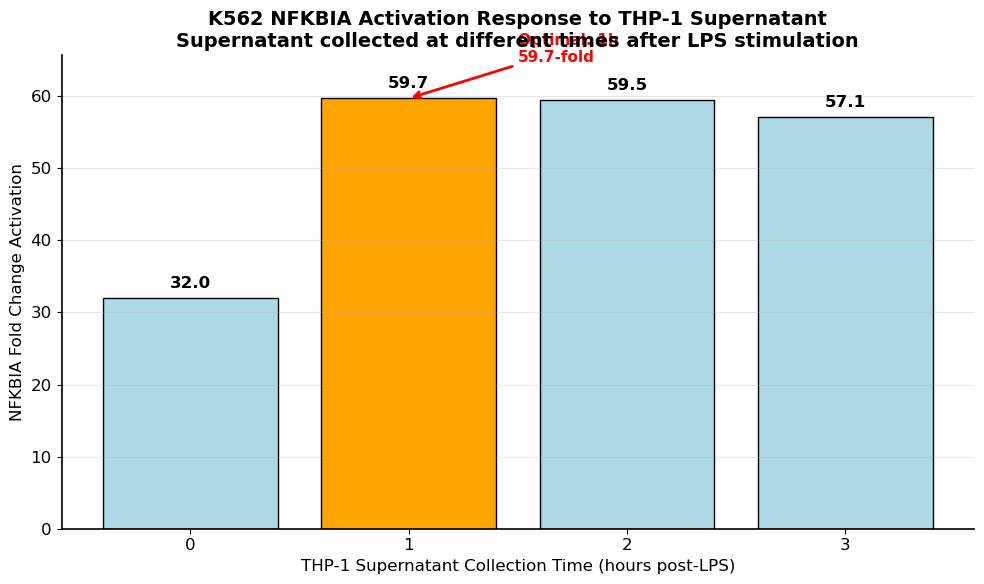

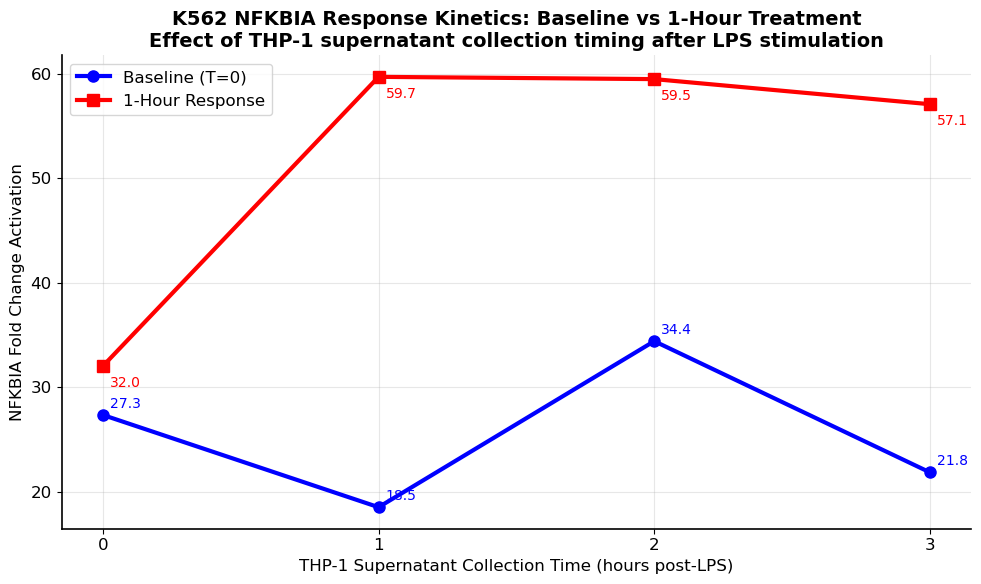

SUMMARY STATISTICS:
Optimal THP-1 collection time: 1 hours
Maximum K562 response: 59.7-fold
Baseline ΔCq used for normalization: 6.363

Complete results table:
   THP1_Collection_Time_Hours  K562_Baseline_Fold_Change  \
0                           0                       27.3   
1                           1                       18.5   
2                           2                       34.4   
3                           3                       21.8   

   K562_1Hr_Response_Fold_Change  Net_Activation  
0                           32.0             4.7  
1                           59.7            41.2  
2                           59.5            25.1  
3                           57.1            35.2  


In [3]:
#Simpler Plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and process the qPCR data
def load_and_process_qpcr_data(file_path):
    """
    Load and process qPCR data from CFX output CSV file
    """
    # Load the data (skip metadata rows and use correct header)
    df = pd.read_csv(file_path, skiprows=19, header=None)

    # Assign column names
    df.columns = ['Well', 'Fluor', 'Target', 'Content', 'Replicate', 
                  'Sample', 'Biological_Set_Name', 'Well_Note', 'Cq', 
                  'Starting_Quantity', 'Cq_Mean', 'Cq_Std_Dev']

    # Remove header row that got included as data
    df = df[df['Well'] != 'Well'].copy()

    # Convert Cq values to numeric
    df['Cq'] = pd.to_numeric(df['Cq'], errors='coerce')

    return df

def calculate_fold_changes(df):
    """
    Calculate fold changes using ΔΔCq method
    """
    # Calculate average Cq values for each condition
    results = []
    for condition in df['Biological_Set_Name'].unique():
        condition_data = df[df['Biological_Set_Name'] == condition]

        nfkbia_cqs = condition_data[condition_data['Sample'] == 'NFKBIA']['Cq'].values
        actb_cqs = condition_data[condition_data['Sample'] == 'ACTB']['Cq'].values

        if len(nfkbia_cqs) > 0 and len(actb_cqs) > 0:
            avg_nfkbia_cq = np.mean(nfkbia_cqs)
            avg_actb_cq = np.mean(actb_cqs)
            delta_cq = avg_nfkbia_cq - avg_actb_cq

            results.append({
                'Condition': condition,
                'Avg_NFKBIA_Cq': avg_nfkbia_cq,
                'Avg_ACTB_Cq': avg_actb_cq,
                'Delta_Cq': delta_cq
            })

    results_df = pd.DataFrame(results)

    # Calculate baseline (No_Stim conditions average)
    baseline_delta_cq = results_df[results_df['Condition'].str.contains('No_Stim')]['Delta_Cq'].mean()

    # Calculate fold changes
    results_df['Delta_Delta_Cq'] = results_df['Delta_Cq'] - baseline_delta_cq
    results_df['Fold_Change'] = 2 ** (-results_df['Delta_Delta_Cq'])

    return results_df, baseline_delta_cq

def prepare_time_course_data(results_df):
    """
    Prepare data for time course analysis
    """
    # Filter time course conditions (exclude controls)
    time_course_mask = ~results_df['Condition'].str.contains('No_Stim|TNFalpha_Stim')
    time_course_data = results_df[time_course_mask].copy()

    # Parse condition names
    def parse_condition(condition):
        parts = condition.split('_')
        thp1_time = int(parts[0])  # Time when THP-1 supernatant was collected
        k562_treatment = int(parts[2])  # 0 = baseline, 1 = after 1 hour
        return thp1_time, k562_treatment

    time_course_data[['THP1_Collection_Time', 'K562_Treatment']] = time_course_data['Condition'].apply(
        lambda x: pd.Series(parse_condition(x))
    )

    return time_course_data

# Load your data (replace with your file path)
file_path = 'Kanishk_K562_Costimulation_LPS_Two_Samples.csv'
df = load_and_process_qpcr_data(file_path)
results_df, baseline_delta_cq = calculate_fold_changes(df)
time_course_data = prepare_time_course_data(results_df)

# Create summary table for plotting
summary_data = []
for thp1_time in [0, 1, 2, 3]:
    t0_data = time_course_data[(time_course_data['THP1_Collection_Time'] == thp1_time) & 
                               (time_course_data['K562_Treatment'] == 0)]
    t1_data = time_course_data[(time_course_data['THP1_Collection_Time'] == thp1_time) & 
                               (time_course_data['K562_Treatment'] == 1)]

    if len(t0_data) > 0 and len(t1_data) > 0:
        summary_data.append({
            'THP1_Collection_Time_Hours': thp1_time,
            'K562_Baseline_Fold_Change': t0_data['Fold_Change'].iloc[0],
            'K562_1Hr_Response_Fold_Change': t1_data['Fold_Change'].iloc[0],
            'Net_Activation': t1_data['Fold_Change'].iloc[0] - t0_data['Fold_Change'].iloc[0]
        })

summary_df = pd.DataFrame(summary_data)

# Plot 1: Bar chart showing K562 1-hour response to different THP-1 collection times
plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df['THP1_Collection_Time_Hours'], 
               summary_df['K562_1Hr_Response_Fold_Change'],
               color=['lightblue' if x != 1 else 'orange' for x in summary_df['THP1_Collection_Time_Hours']],
               edgecolor='black', linewidth=1)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('K562 NFKBIA Activation Response to THP-1 Supernatant\nSupernatant collected at different times after LPS stimulation', 
          fontsize=14, fontweight='bold')
plt.xlabel('THP-1 Supernatant Collection Time (hours post-LPS)', fontsize=12)
plt.ylabel('NFKBIA Fold Change Activation', fontsize=12)
plt.ylim(0, max(summary_df['K562_1Hr_Response_Fold_Change']) * 1.1)
plt.xticks(summary_df['THP1_Collection_Time_Hours'])
plt.grid(axis='y', alpha=0.3)

# Add annotation for optimal condition
optimal_idx = summary_df['K562_1Hr_Response_Fold_Change'].idxmax()
optimal_time = summary_df.loc[optimal_idx, 'THP1_Collection_Time_Hours']
optimal_value = summary_df.loc[optimal_idx, 'K562_1Hr_Response_Fold_Change']
plt.annotate(f'Optimal: {optimal_time}h\n{optimal_value:.1f}-fold', 
             xy=(optimal_time, optimal_value), 
             xytext=(optimal_time + 0.5, optimal_value + 5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Plot 2: Line chart comparing baseline vs 1-hour responses
plt.figure(figsize=(10, 6))

plt.plot(summary_df['THP1_Collection_Time_Hours'], 
         summary_df['K562_Baseline_Fold_Change'], 
         marker='o', linewidth=3, markersize=8, 
         label='Baseline (T=0)', color='blue')

plt.plot(summary_df['THP1_Collection_Time_Hours'], 
         summary_df['K562_1Hr_Response_Fold_Change'], 
         marker='s', linewidth=3, markersize=8, 
         label='1-Hour Response', color='red')

# Add data point labels
for i, row in summary_df.iterrows():
    plt.annotate(f'{row["K562_Baseline_Fold_Change"]:.1f}', 
                xy=(row['THP1_Collection_Time_Hours'], row['K562_Baseline_Fold_Change']),
                xytext=(5, 5), textcoords='offset points', 
                fontsize=10, color='blue')
    plt.annotate(f'{row["K562_1Hr_Response_Fold_Change"]:.1f}', 
                xy=(row['THP1_Collection_Time_Hours'], row['K562_1Hr_Response_Fold_Change']),
                xytext=(5, -15), textcoords='offset points', 
                fontsize=10, color='red')

plt.title('K562 NFKBIA Response Kinetics: Baseline vs 1-Hour Treatment\nEffect of THP-1 supernatant collection timing after LPS stimulation', 
          fontsize=14, fontweight='bold')
plt.xlabel('THP-1 Supernatant Collection Time (hours post-LPS)', fontsize=12)
plt.ylabel('NFKBIA Fold Change Activation', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(summary_df['THP1_Collection_Time_Hours'])

plt.tight_layout()
plt.show()

# Print summary statistics
print("SUMMARY STATISTICS:")
print("=" * 50)
print(f"Optimal THP-1 collection time: {optimal_time} hours")
print(f"Maximum K562 response: {optimal_value:.1f}-fold")
print(f"Baseline ΔCq used for normalization: {baseline_delta_cq:.3f}")
print()
print("Complete results table:")
print(summary_df.round(1))
